<a href="https://colab.research.google.com/github/AnchalPandey29/Object-Classification/blob/main/ObjectC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers,models

In [ ]:
(x_train,y_train),(x_test,y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

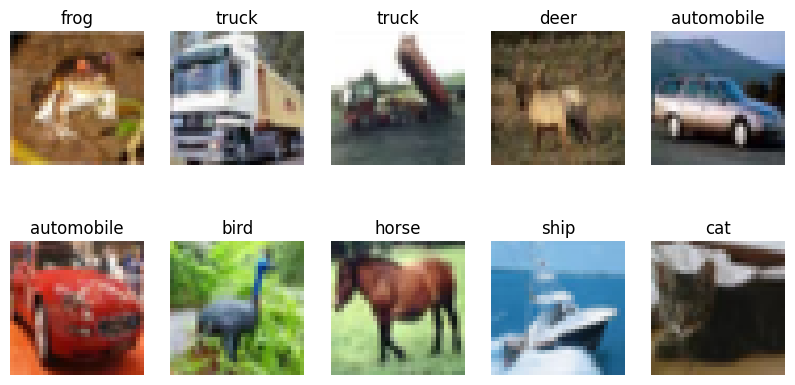

In [ ]:
plt.figure(figsize=(10,5))

for  i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i])
  plt.title(classes[y_train[i][0]])
  plt.axis("off")
plt.show()

In [ ]:
x_train = x_train/255
x_test = x_test/255

In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation="relu",input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation="relu"))

model.add(layers.Flatten())

model.add(layers.Dense(64,activation="relu"))
model.add(layers.Dense(10,activation="softmax"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [ ]:
history = model.fit(
    x_train, y_train, epochs = 10,validation_data=(x_test,y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 56ms/step - accuracy: 0.4403 - loss: 1.5276 - val_accuracy: 0.5478 - val_loss: 1.2653
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 91s 58ms/step - accuracy: 0.5859 - loss: 1.1664 - val_accuracy: 0.6188 - val_loss: 1.0813
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.6475 - loss: 1.0066 - val_accuracy: 0.6431 - val_loss: 1.0039
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.6824 - loss: 0.9039 - val_accuracy: 0.6605 - val_loss: 0.9828
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 50ms/step - accuracy: 0.7083 - loss: 0.8352 - val_accuracy: 0.6910 - val_loss: 0.8827
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 54ms/step - accuracy: 0.7335 - loss: 0.7709 - val_accuracy: 0.6967 - val_loss: 0.8933
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.7469 - loss: 0.7246 - val_accuracy: 0.6990 - val_loss: 0.8836
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.7634 -

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test,y_test)
print("Accuracy",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7036 - loss: 0.9053
Accuracy 0.7035999894142151


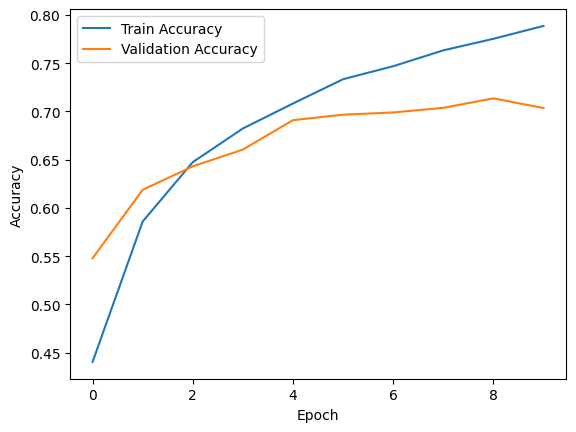

In [ ]:
plt.plot(history.history['accuracy'],label="Train Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
predictions = model.predict(x_test)

predicted_label = np.argmax(predictions[1])
print("Predicted label :",predicted_label)
print("Predicted class :",classes[predicted_label])

print("Actual label: ",y_test[1][0])
print("Actual label: ",classes[y_test[1][0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Predicted label : 8
Predicted class : ship
Actual label:  8
Actual label:  ship


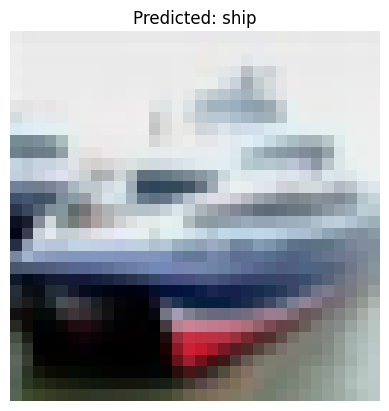

In [ ]:
plt.imshow(x_test[1],cmap="gray")
plt.title(f"Predicted: {classes[predicted_label]}")
plt.axis("off")
plt.show()